# **Variational AutoEncoders (VAE)**
This notebook covers the training of a VAE on FashionMNIST dataset.

In the following sections, we shall:


1.   Explore the FashionMNIST dataset
2.   Implement a custom sampling layer
3.   Implement encoder/decoder models using Functional APIs
4.   Implement loss functions
5.   Override Keras model train_step
6.   Train the VAE model
7.   Explore the results

First make sure we have a GPU available, or this will take a really long time to train. If you don't, refer to https://www.tensorflow.org/install/gpu

In [1]:
# bibliotecas
import tensorflow as tf
import os
import random
import numpy as np

# confirmando se a GPU 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-05-20 10:30:24.032181: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-20 10:30:24.490905: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 10:30:26.433872: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Num GPUs Available:  0


2026-05-20 10:30:28.409005: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Let's also set a consistent random seed to help make the results of this notebook more, well, consistent.

In [2]:
SEED = 123456
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1' # flag para determinismo no tensorflow 2.0+
random.seed(SEED)# seed para a biblioteca random padrão
np.random.seed(SEED) # seed para o numpy
tf.random.set_seed(SEED) # seed para o tensorflow

## Exploring the FashionMNIST data set ##

FashionMNIST is like the handwriting recognition MNIST dataset we know and love, but with pictures of different kinds of clothes instead of pictures of people writing digits.

<h2>Available Labels/Classes</h2>

<table align="left">
<thead>
<tr>
<th align="center">Label</th>
<th>Description</th>
</tr>
</thead>
<tbody>
<tr>
<td align="center">0</td>
<td>T-shirt/top</td>
</tr>
<tr>
<td align="center">1</td>
<td>Trouser</td>
</tr>
<tr>
<td align="center">2</td>
<td>Pullover</td>
</tr>
<tr>
<td align="center">3</td>
<td>Dress</td>
</tr>
<tr>
<td align="center">4</td>
<td>Coat</td>
</tr>
<tr>
<td align="center">5</td>
<td>Sandal</td>
</tr>
<tr>
<td align="center">6</td>
<td>Shirt</td>
</tr>
<tr>
<td align="center">7</td>
<td>Sneaker</td>
</tr>
<tr>
<td align="center">8</td>
<td>Bag</td>
</tr>
<tr>
<td align="center">9</td>
<td>Ankle boot</td>
</tr>
</tbody>
</table>

Let's import the data set and check its dimensions. Each image is 28x28, with 60000 training samples and 10000 test.

In [3]:
from tensorflow.keras.datasets import fashion_mnist

# carregar o dataset fashion mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# garantir que os dados tem o formato correto antes de continuar
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

It's always a good idea to inspect the data and get a feel for it, so let's visualize a few samples to see what they look like.

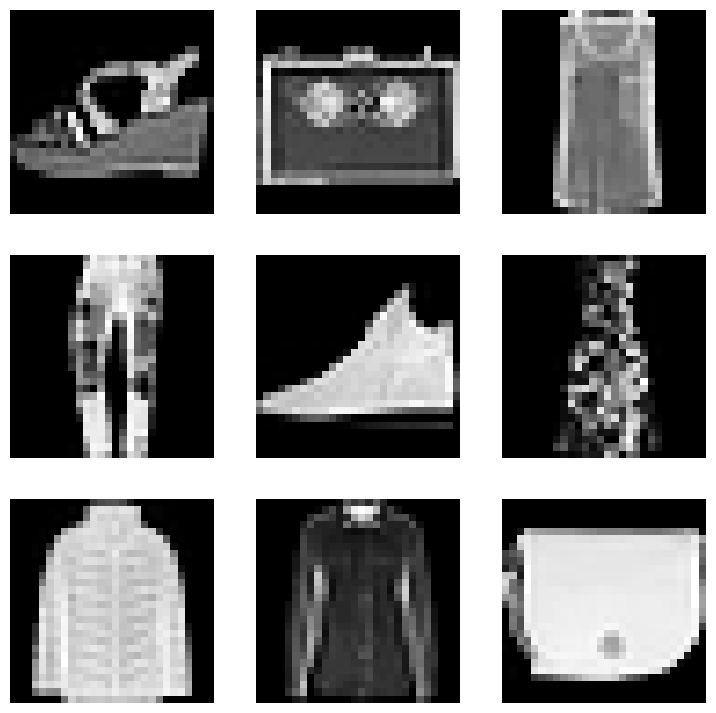

In [4]:
import numpy as np
from matplotlib import pyplot as plt

plt.figure(figsize=(9, 9))

# Seleciona 9 amostras aleatórias
rndSamples = np.random.choice(60000, 9)

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[rndSamples[i]], cmap="Greys_r")
    plt.axis('off')

plt.show();

We need to preprocess the data a bit before it is suitable for using with generative modeling. First, we are going to combine our training and test data together because generative models don't work via train/test measuring classification accuracy, they measure how similar generated images are to the original, using visual perception methods such as FID/IS (Frechet Inception Distance and Inception Score.) So we really just need a big pile of images.

We also need to normalize the data; the raw pixel data is in the range 0-255, but sigmoid activation values are 0-1, so we'll scale all the pixels to 0-1 by just dividing them by 255.

And, we need to add an extra dimension since convolutional layers expect 3 channels.

In [5]:
dataset = np.concatenate([x_train, x_test], axis=0)
# muda as imagens de 28x28 para 28x28x1
# as camadas de convolução precisam da dimensao
dataset = np.expand_dims(dataset, -1).astype("float32") / 255

## Custom Sampling Layer ##

Our encoder is trying to learn a probability distribution z given data X. The distribution is defined by Mu and Sigma.

Then, the decoder samples randomly from the z distribution.

The problem is that the random sampling is not differentiable, which is needed for backpropagation training. But by introducing a parameter Epsilon we make it a deterministic, differentiable operation.

In [6]:
from tensorflow import keras
from tensorflow.keras import layers


# criar uma camada de amostragem
class SamplingLayer(layers.Layer):
  """Reparameterization Trick z = mu + sigma * epsilon"""

  def call(self, inputs):
    # separar a média e o logaritmo da variância
    zMean, zLogVar = inputs
    # obter o tamanho do lote e a dimensão do espaço latente
    batch = tf.shape(zMean)[0]
    dim = tf.shape(zMean)[1]
    # criar o ruído aleatório a partir de uma distribuição normal padrão
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    # aplicar a fórmula para gerar o vetor z amostrado
    return zMean + tf.exp(0.5 * zLogVar) * epsilon

## Encoder / Decoder ##

Our encoder uses Keras functional API's to create a non-sequential model, as we need to output two values in parallel (mean and variance.)

In [7]:
def buildEncoder(latentDim, encoderInputs):

  # o bloco de convolução extrai as características das imagens
  l1 = keras.models.Sequential([
    layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),
    layers.Flatten(),
    layers.Dense(256, activation="relu")
  ])

  # passar as entradas pelo bloco convolucional
  x = l1(encoderInputs)

  # camada dedicada para aprender a média em paralelo
  zMean = layers.Dense(latentDim, name="z_mean")(x)

  # camada dedicada para aprender a variância em paralelo
  zLogVar = layers.Dense(latentDim, name="z_log_var")(x)

  # truque da reparametrização para achar z usando a média e a variância
  z = SamplingLayer()([zMean, zLogVar])

  # o modelo recebe as imagens e retorna a média, variância e a distribuição z
  return keras.Model(encoderInputs, [zMean, zLogVar, z], name="encoder")


# chamar a função para construir o modelo na prática
encoderInputs = keras.Input(shape=(28, 28, 1))
encoder = buildEncoder(2, encoderInputs)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256)       │    878,144 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 879,172 (3.35 MB)

 Trainable params: 879,172 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

And now we'll implement the decoder in a similar fashion. Note the use of Conv2DTranspose instead of Conv2D; we use the transpose convolution to generate images going from lower resolutions to higher ones. That's the real heart of this technique.

In [8]:
def buildDecoder(latentInputs):

  # o bloco sequencial reconstrói a imagem a partir do vetor
  l1 = keras.models.Sequential([
    layers.Dense(7*7*64, activation="relu", input_shape=(latentInputs.shape[1],)),
    layers.Reshape((7,7,64)),
    layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
  ])

  # o modelo recebe as coordenadas latentes e entrega a imagem reconstroi
  return keras.Model(latentInputs, l1(latentInputs), name="decoder")

# chamar a função para construir o modelo
latentInputs = keras.Input(shape=(2,))
decoder = buildDecoder(latentInputs)
decoder.summary()

/home/Ront/banana/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       157,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,633 (615.75 KB)

 Trainable params: 157,633 (615.75 KB)

 Non-trainable params: 0 (0.00 B)

## Loss Functions ##

VAE has TWO loss functions! First is the reconstruction loss, which penalizes images that are not similar to the original images.

In [9]:
def reconstructionLoss(data, reconstructed):
  # calcula a perda comparando a imagem original com a reconstruída
  return tf.reduce_mean(
      tf.reduce_sum(
          keras.losses.binary_crossentropy(data, reconstructed),
          axis=(1, 2)
      )
  )

Next we have the Kullback-Liebler Divergence loss function, also called Earth Mover loss from the analogy of figuring out how much dirt needs to be moved to transform the shape of the UK to the shape of the US.

What it really does is measure the distance between two probability distributions. It penalizes the model if it learns a probability distribution "z" that is different from the original probability distribution of the data "X".

Mathematically it is the same thing as cross-entropy - entropy, which means it works well for backpropagation and log-likelihood minimization.

In [10]:
def klDivergenceLoss(zMean, zLogVar):
  # calcula a perda kl para regularizar o espaço latente
  return tf.reduce_mean(
      tf.reduce_sum(
          -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
          axis=1
      )
  )

So now we'll combine these into the total loss function, which just weights them and sums them up. Think of that weight (alpha) as another hyperparameter you can tune.

In [11]:
def calcTotalLoss(data, reconstructed, zMean, zLogVar):
  loss1 = reconstructionLoss(data, reconstructed) # calcula a perda de reconstrução da imagem
  loss2 = klDivergenceLoss(zMean, zLogVar) # calcula a perda por divergência kl
  # peso para equilibrar o impacto das duas perdas no treino
  klWeight = 3.0
  return  loss1, loss2, loss1 + klWeight * loss2

## Overriding train_step ##

Since we are using a custom loss function on mu and sigma, we need to override how the loss is calculated. We need to compare X_original and X_reconstructed at the same time while calculating the Kullback-Liebler (KL) loss.

In [12]:
class VAE(keras.Model):
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    # registrar a perda total como uma metrica
    self.totalLossTracker = keras.metrics.Mean(name="total_loss")
    self.ceLossTracker = keras.metrics.Mean(name="ce_loss")
    self.klLossTracker = keras.metrics.Mean(name="kl_loss")

  # estas são todas as metricas
  @property
  def metrics(self):
    return [
        self.totalLossTracker,
        self.ceLossTracker,
        self.klLossTracker
    ]

  # calcula a perda os gradientes e atualiza os pesos
  def train_step(self, data):
    # o gradient tape registra os gradientes dos pesos treinaveis para atualização
    with tf.GradientTape() as tape:
        zMean, zLogVar, z = self.encoder(data)
        reconstruction = self.decoder(z)
        ceLoss, klLoss, totalLoss = calcTotalLoss(data, reconstruction, zMean, zLogVar)
        
    # passo de volta (backward path)
    grads = tape.gradient(totalLoss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    # atualizar o rastreamento das perdas
    self.totalLossTracker.update_state(totalLoss)
    self.ceLossTracker.update_state(ceLoss)
    self.klLossTracker.update_state(klLoss)

    # retorna as perdas para o objeto de histórico do treino
    return {
        "total_loss": self.totalLossTracker.result(),
        "ce_loss": self.ceLossTracker.result(),
        "kl_loss": self.klLossTracker.result()
    }

## Train the VAE! ##

In [13]:
vae = VAE(encoder, decoder)# inicializar o modelo vae completo juntando
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))# configurar o otimizador adam 
history = vae.fit(dataset, epochs=32, batch_size=128)# treinar o modelo passand

Epoch 1/32


2026-05-20 10:30:40.410995: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 219520000 exceeds 10% of free system memory.


547/547 ━━━━━━━━━━━━━━━━━━━━ 91s 162ms/step - ce_loss: 300.3275 - kl_loss: 3.8129 - total_loss: 311.7660
Epoch 2/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 93s 169ms/step - ce_loss: 264.2346 - kl_loss: 4.5863 - total_loss: 277.9933
Epoch 3/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 93s 170ms/step - ce_loss: 260.7233 - kl_loss: 4.6867 - total_loss: 274.7833
Epoch 4/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 91s 167ms/step - ce_loss: 259.0491 - kl_loss: 4.7673 - total_loss: 273.3511
Epoch 5/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 97s 178ms/step - ce_loss: 257.8329 - kl_loss: 4.8317 - total_loss: 272.3279
Epoch 6/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 89s 163ms/step - ce_loss: 256.6941 - kl_loss: 4.8741 - total_loss: 271.3167
Epoch 7/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 88s 161ms/step - ce_loss: 255.9452 - kl_loss: 4.9335 - total_loss: 270.7458
Epoch 8/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 93s 171ms/step - ce_loss: 255.3650 - kl_loss: 4.9708 - total_loss: 270.2773
Epoch 9/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 95s 173ms/step - ce_loss: 254.8879 - kl_los

Let's visualize how the loss functions changed over each epoch; this can inform at what point it makes sense to stop.

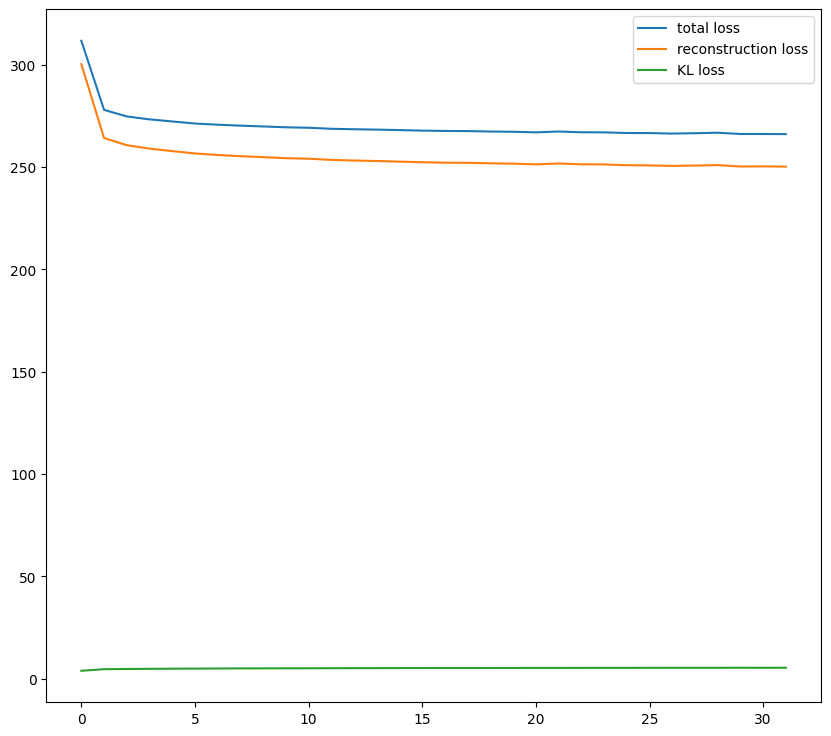

In [18]:
plt.figure(figsize=(10, 9))# definir o tamanho da janela do gráfico
plt.plot(history.history.get('total_loss'), label="total loss") # plotar a curva da perda total ao longo das épocas
plt.plot(history.history.get('ce_loss'), label="reconstruction loss") # plotar a curva da perda de reconstrução
plt.plot(history.history.get('kl_loss'), label="KL loss")# plotar a curva da perda da divergência kl

# exibir a legenda para identificar cada linha do gráfico
plt.legend();

Let's zoom into the KL loss so we can see it better:

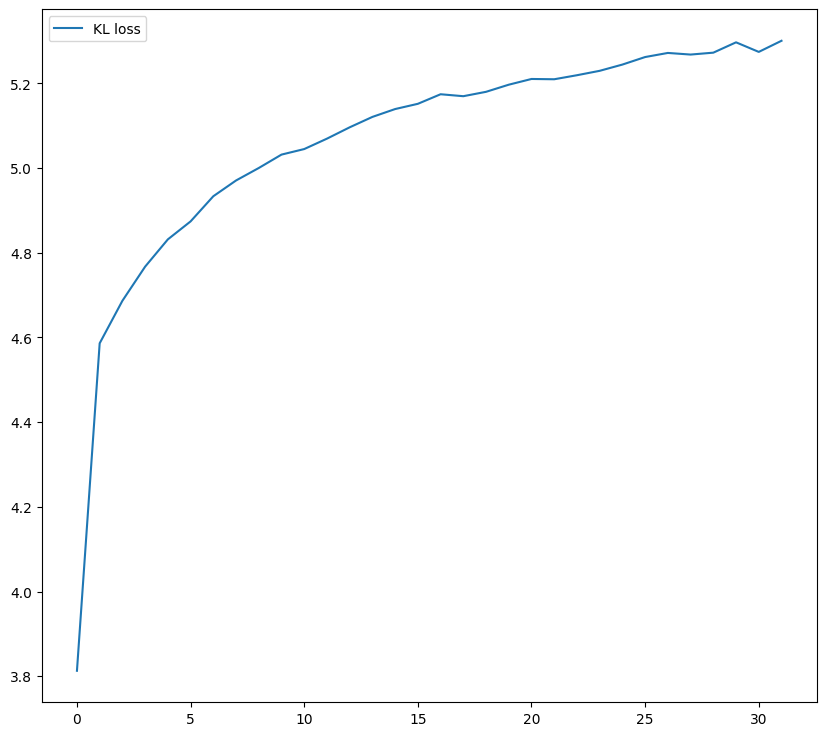

In [19]:
plt.figure(figsize=(10, 9)) # definir o tamanho da janela do gráfico
plt.plot(history.history.get('kl_loss'), label="KL loss") # plotar a curva da perda da divergência kl 
plt.legend();# exibir a legenda para identificar a linha no gráfico

# Explore the results ##

Let's use a mean (mu) of 1 and variance (sigma) of 2 (just a guess to start with). Play around with this, try different values to get different types of objects (shirts, bags, etc.)

In [26]:
# Vamos agora pegar uma imagem do dataset e ver como o modelo a representa no espaço latente
idx = 1280 # índice da imagem que queremos analisar
batch = np.expand_dims(x_train[idx], axis=0) # expandindo as dimensões para criar um batch de tamanho 1
batchOfImages = np.expand_dims(batch, axis=-1).astype("float32") / 255 # normalizando a imagem
print(batchOfImages.shape)
_, _, z = vae.encoder.predict(batchOfImages)

synth = vae.decoder.predict([z])

z

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([[0.00988378, 1.2979611 ]], dtype=float32)

Let's generate 256 images entirely at random. All we have to do is guess the Z distribution (defined by mu, sigma). Don't worry, we will get to a systematic method to determine the mu and sigma for each category.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


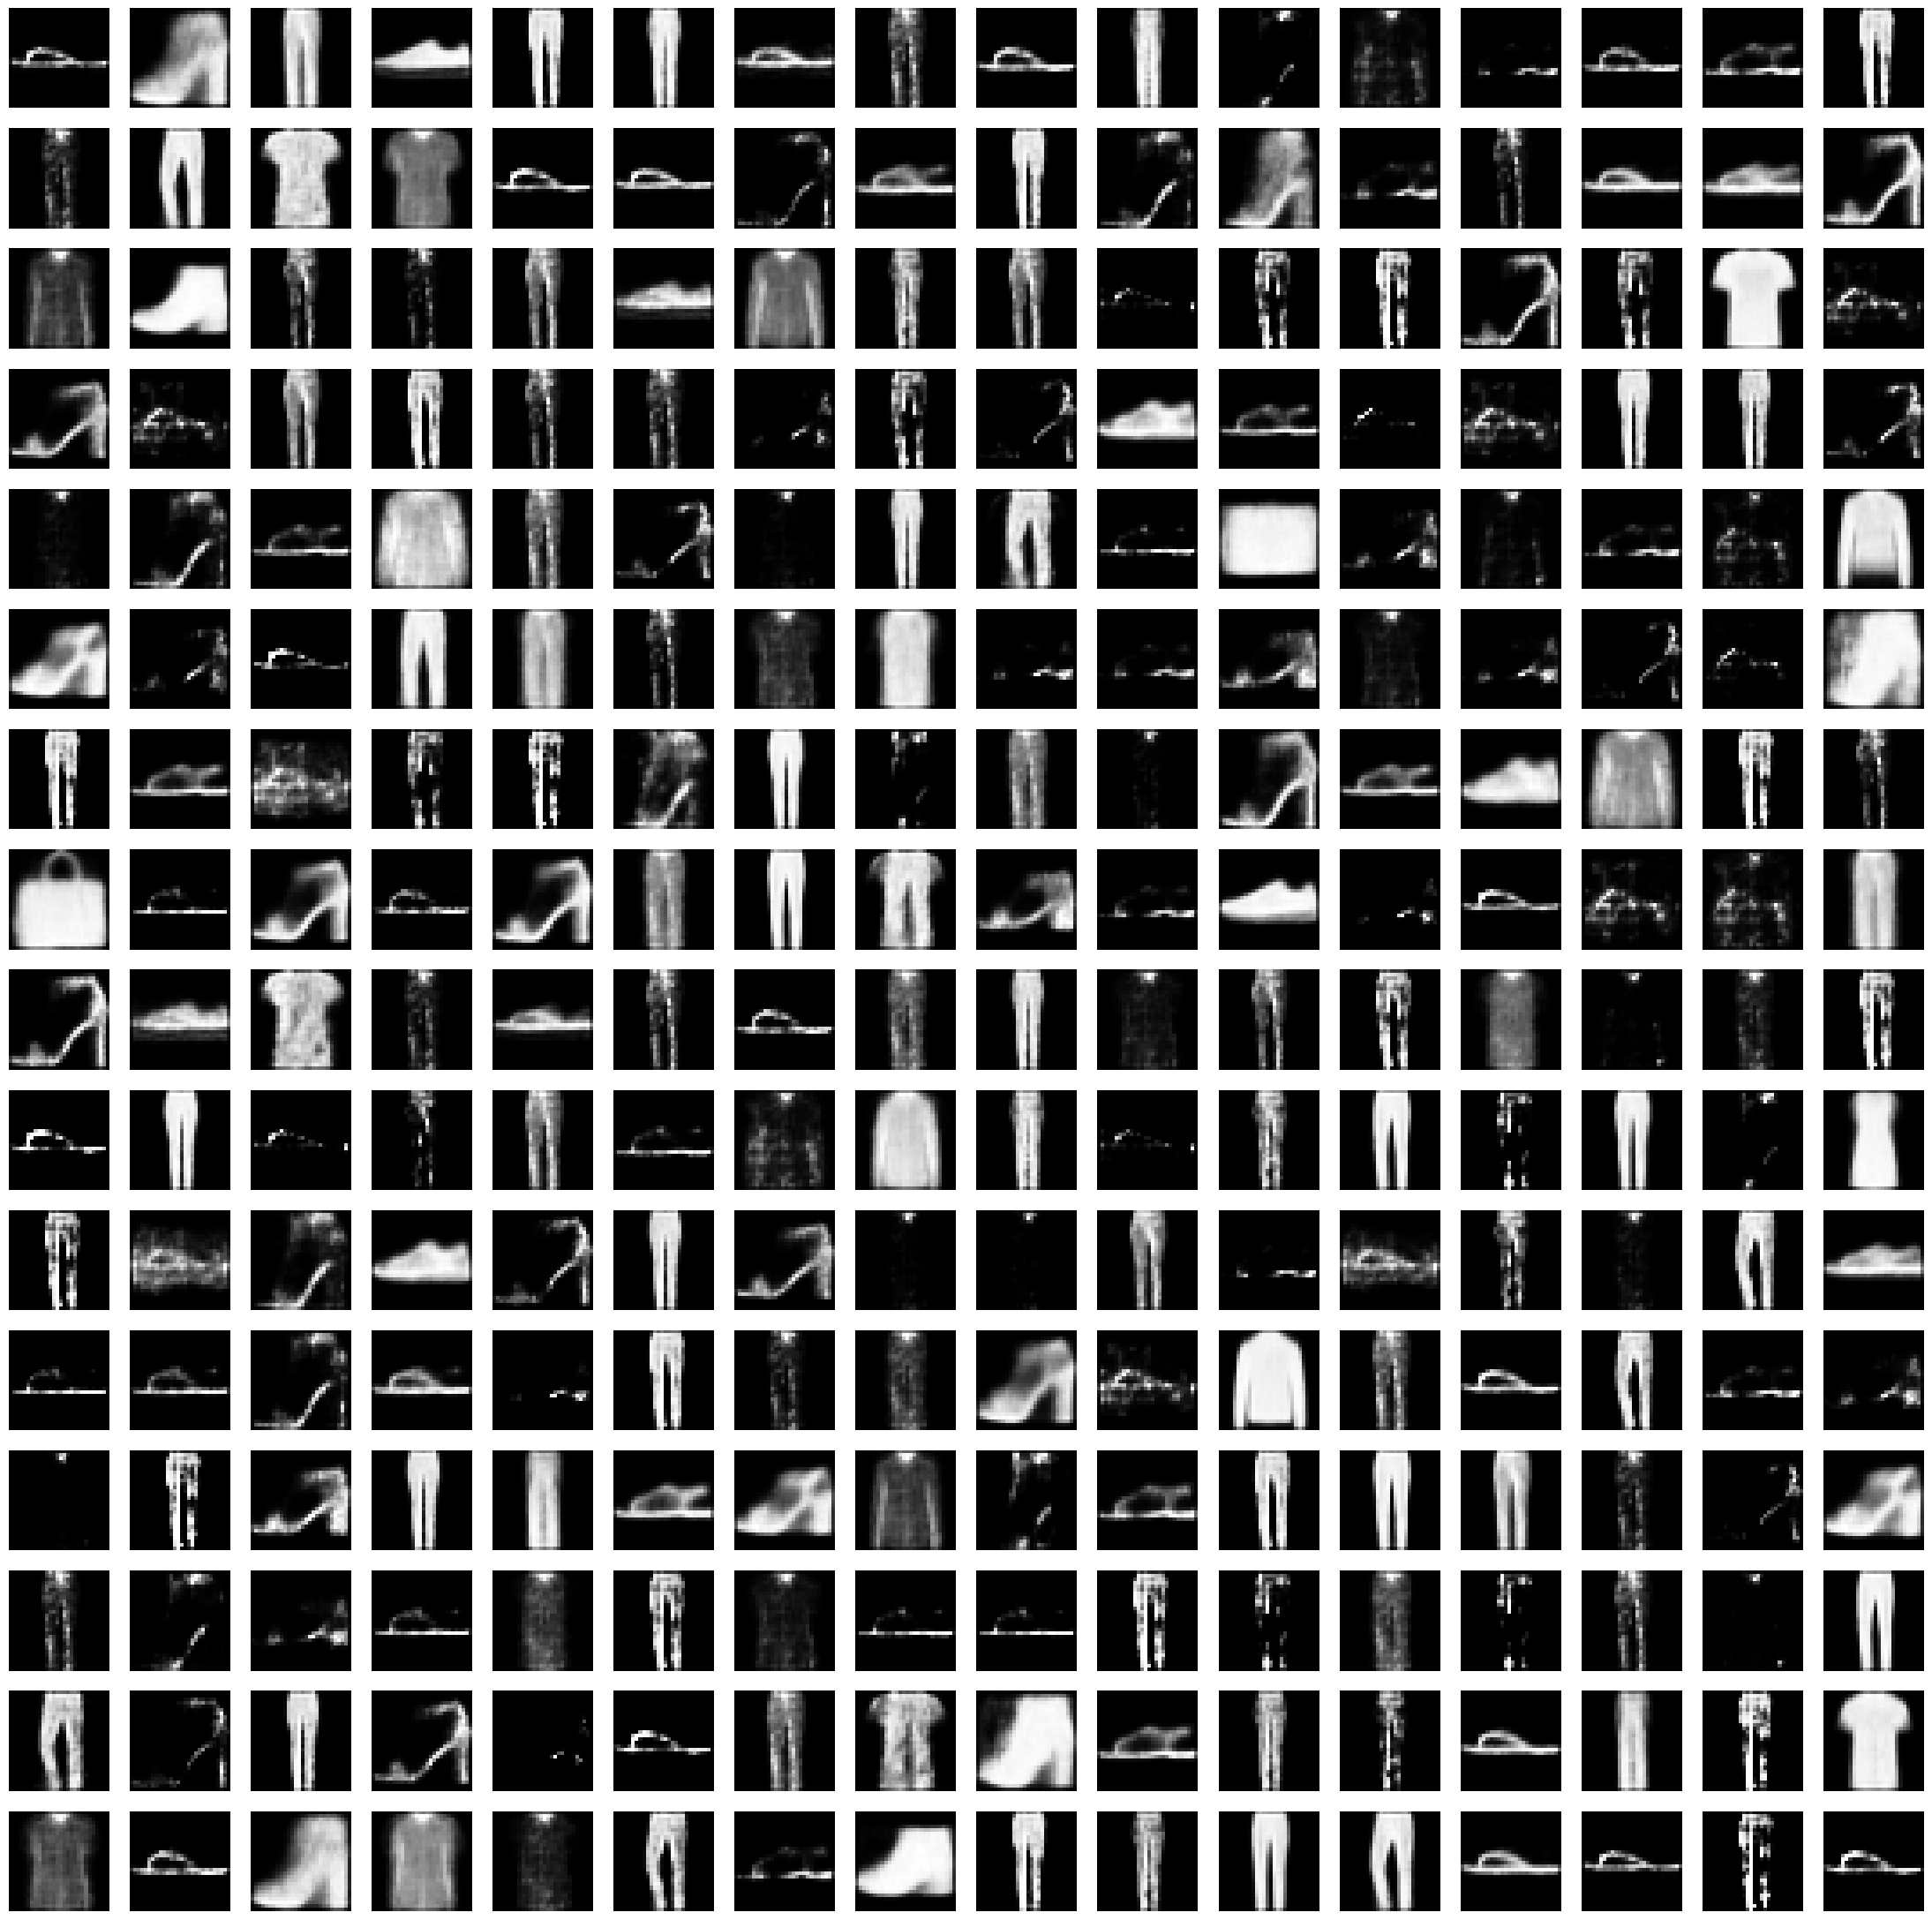

In [21]:
z = np.random.normal(loc=0, scale=4, size=(256,2))# gerar 256 pontos aleatórios
synth = vae.decoder.predict(z)# usar o decoder para gerar imagens
plt.figure(figsize=(28,28))# definir o tamanho da janela 

for i in range(256):# percorrer as 256 imagens geradas
    plt.subplot(16,16,i+1) # criar uma sub-grade de 16x16 para organizar as fotos
    plt.imshow(synth[i].reshape((28,28)), cmap="Greys_r")# redimensionar cada imagem 
    plt.axis('off') # ocultar as bordas e eixos

plt.show();

As promised, we can find the mapping of mu and sigma for each category. Just map an image from each category through the encoder and observe the output. Then use those outputs to conditionally instruct the decoder to sample from a particular category. This isn't a guaranteed solution though - for concrete results look up "Conditional Variational AutoEncoders".

In [22]:
idx = 1280
batch = np.expand_dims(x_train[idx], axis=0)
# adicionar a dimensão dos canais 
batchOfImages = np.expand_dims(batch, axis=-1).astype("float32") / 255
print(batchOfImages.shape)

# obter o vetor z
_, _, z = vae.encoder.predict(batchOfImages)

# reconstruir uma imagem semelhante a partir desse vetor z
synth = vae.decoder.predict([z])
z

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


/home/Ront/banana/lib64/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=('Tensor(shape=(1, 2))',)
  warnings.warn(msg)


array([[0.03196477, 1.4634966 ]], dtype=float32)

Note that the reconstructed image could be different from the original, depending on how long the model has been trained and whether it has reached a global minima.

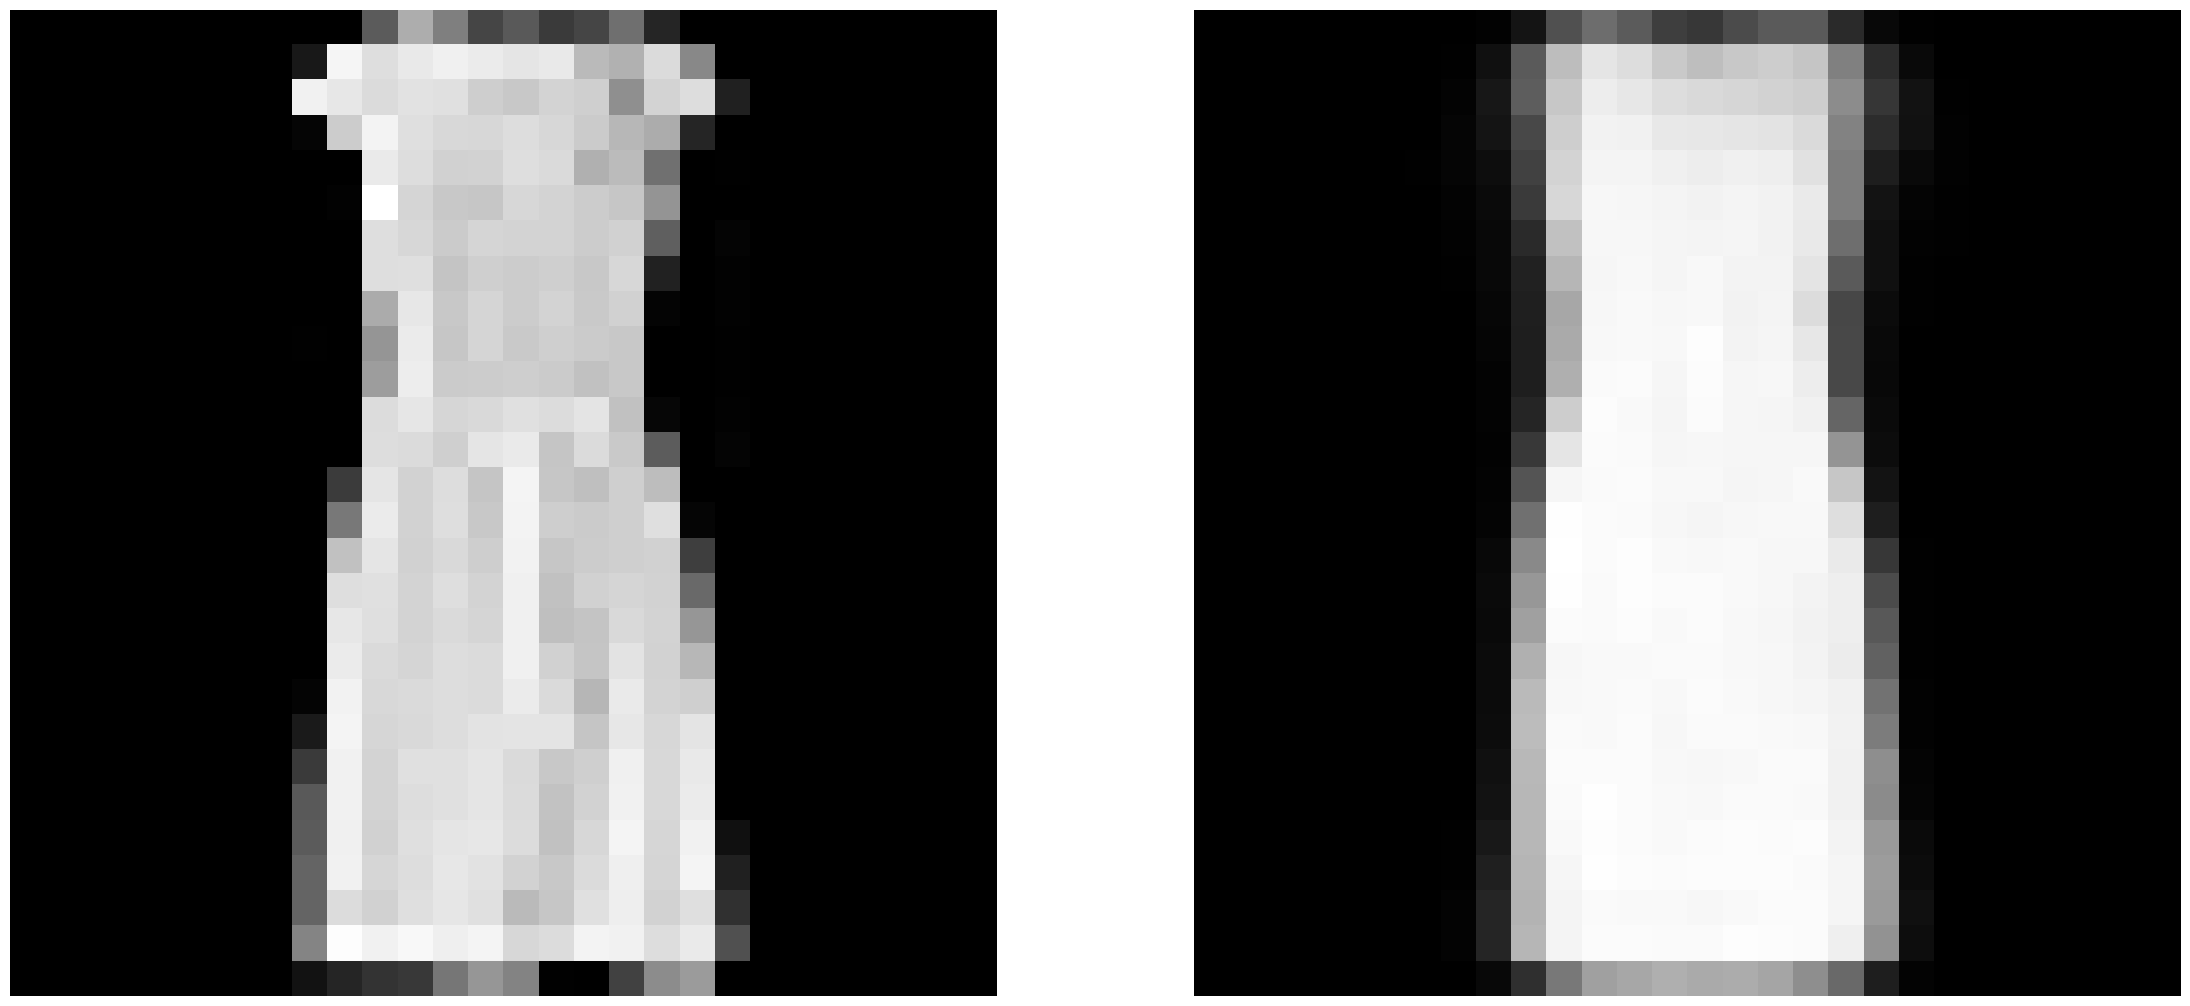

In [23]:
# definir o tamanho da janela do gráfico
plt.figure(figsize=(28, 28))

# imagem original
plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(x_train[idx], cmap="Greys_r")


# imagem reconstruída pelo decoder
plt.subplot(1,2,2)
plt.axis('off')
# redimensionar a imagem gerada 
plt.imshow(synth[0].reshape((28,28)), cmap="Greys_r")
plt.show();

  36/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step 

2026-05-20 11:26:01.671643: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 219520000 exceeds 10% of free system memory.


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step


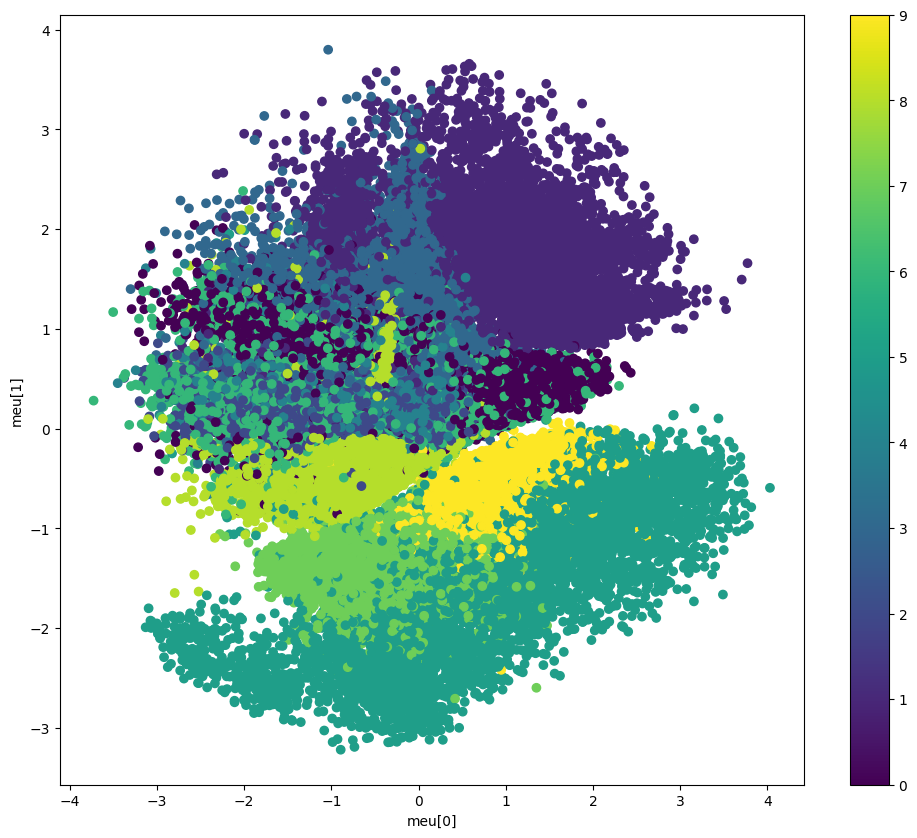

In [25]:
"""
VAE can be used in unsupervised learning of large text or unlabeled images corpus
to cluster the samples into categories
"""
labels = np.concatenate([y_train, y_test], axis=0)# concatenar os rótulos de treino e teste em um único array
meu, _, _ = vae.encoder.predict(dataset)# concatenar os rótulos de treino
plt.figure(figsize=(12, 10))# definir o tamanho da janela do gráfico
plt.scatter(meu[:, 0], meu[:, 1], c=labels)# criar o gráfico de dispersão colorindo
plt.colorbar()# exibir a barra de cores lateral como legenda das classes

# definir os nomes dos eixos x e y
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")

plt.show();